In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
import dask.dataframe as dd
import dask.array as da
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp
import tables

sys.path.insert(0, "/data/user/akatil/electron_neutrino/for_real/analysis_chain/")

from analysis_helpers import get_mean_upgrade_positions

In [2]:
#getting the geometry frame. We want this to calculate the mean of upgrade om x and y positions
gcd_infile = dataio.I3File('/home/akatil/GeoCalibDetectorStatus_ICUpgrade.v58.mixed.V1.i3.bz2')

f_geo = gcd_infile
geo_frame = f_geo.pop_frame(icetray.I3Frame.Geometry)
geo = geo_frame['I3Geometry']

ux, uy, uz = get_mean_upgrade_positions(geo)

fCC = tables.open_file('../../../dataset_complete/merger/merged_CC.h5', mode='r')
fNC = tables.open_file('../../../dataset_complete/merger/merged_NC.h5', mode='r')

In [3]:
emin, emax = 0, 100

imin, imax = 0, 0.1

#interaction_type = 0

#f = fCC

def get_boolean(f, interaction_type):
    event_counter = f.root.EventCounter.col("value")
    print(event_counter)
    print('started counter')
    
    #energy = f.root.PrimaryEnergy.col("value")#f.root.PrimaryEnergy.col("value")
    #inelasticity = f.root.Inelasticity.col("value")
    
    trueX = f.root.TrueX.col("value")
    trueY = f.root.TrueY.col("value")
    trueZ = f.root.TrueZ.col("value")
    
    #energy_boolean = (energy >= emin) & (energy <= emax)
    #inelasticity_boolean = (inelasticity >= imin) & (inelasticity <= imax)
    
    vertex_boolean = (trueZ <= uz+150)&(trueZ >= uz-150)&(trueX <= ux+50)&(trueX >= ux-50)&(trueY <= uy+40)&(trueY >= uy-40)
    print('defined booleans')
    
    if interaction_type == 0:
        energy = f.root.PrimaryEnergy.col("value")
        energy_boolean = (energy >= emin) & (energy <= emax)
        
        inelasticity = f.root.Inelasticity.col("value")
        inelasticity_boolean = (inelasticity >= imin) & (inelasticity <= imax)
        
        event_boolean = energy_boolean & inelasticity_boolean & vertex_boolean
    if interaction_type == 1:
        energy = f.root.SecondaryEnergy.col("value")
        energy_boolean = (energy >= emin) & (energy <= emax)
        
        event_boolean = energy_boolean & vertex_boolean

    return event_boolean

In [4]:
event_booleanCC = get_boolean(fCC, 0)
event_booleanNC = get_boolean(fNC, 1)

[1.00000737e+10 1.00000737e+10 1.00000737e+10 ... 1.00025629e+10
 1.00025629e+10 1.00025629e+10]
started counter
defined booleans
[2.00000000e+10 2.00000000e+10 2.00000000e+10 ... 2.00022403e+10
 2.00022403e+10 2.00022403e+10]
started counter
defined booleans


In [5]:
def make_plots(true_xCC, true_yCC, 
               true_xNC, true_yNC, 
               reco_xCC, reco_yCC,
               reco_xNC, reco_yNC,
               bins, 
               xlabel, ylabel):

    
    true_xCC_m = true_xCC[~np.isnan(true_xCC)]
    true_yCC_m = true_yCC[~np.isnan(true_xCC)]
    true_xNC_m = true_xNC[~np.isnan(true_xNC)]
    true_yNC_m = true_yNC[~np.isnan(true_xNC)]
    reco_xCC_m = reco_xCC[~np.isnan(reco_xCC)]
    reco_yCC_m = reco_yCC[~np.isnan(reco_xCC)]
    reco_xNC_m = reco_xNC[~np.isnan(reco_xNC)]
    reco_yNC_m = reco_yNC[~np.isnan(reco_xNC)]

    fig, axs = plt.subplots(1, 2)
    fig.set_figheight(8)
    fig.set_figwidth(20)
    
    a0 = axs[0].hist2d(true_xCC_m, true_yCC_m, cmap='jet', norm=LogNorm(), density=True, bins=bins)
    fig.colorbar(a0[3], ax=axs[0])
    axs[0].set_xlabel(xlabel, fontsize = 18)
    axs[0].set_ylabel(ylabel, fontsize = 18)
    axs[0].set_title('CC - Energy {} - {} GeV|True'.format(emin, emax))

    #print(len(xNC), len(yNC))
    a1 = axs[1].hist2d(true_xNC_m, true_yNC_m, cmap='jet', norm=LogNorm(), density=True, bins=bins)
    fig.colorbar(a1[3], ax=axs[1])
    axs[1].set_xlabel(xlabel, fontsize = 18)
    axs[1].set_ylabel(ylabel, fontsize = 18)
    axs[1].set_title('NC - Charge {} - {} GeV|True'.format(emin, emax))
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

    fig, axs = plt.subplots(1, 2)
    fig.set_figheight(8)
    fig.set_figwidth(20)
    
    a0 = axs[0].hist2d(reco_xCC_m, reco_yCC_m, cmap='jet', norm=LogNorm(), density=True, bins=bins)
    fig.colorbar(a0[3], ax=axs[0])
    axs[0].set_xlabel(xlabel, fontsize = 18)
    axs[0].set_ylabel(ylabel, fontsize = 18)
    axs[0].set_title('CC - Energy {} - {} GeV|Reco'.format(emin, emax))

    #print(len(xNC), len(yNC))
    a1 = axs[1].hist2d(reco_xNC_m, reco_yNC_m, cmap='jet', norm=LogNorm(), density=True, bins=bins)
    fig.colorbar(a1[3], ax=axs[1])
    axs[1].set_xlabel(xlabel, fontsize = 18)
    axs[1].set_ylabel(ylabel, fontsize = 18)
    axs[1].set_title('NC - Charge {} - {} GeV|Reco'.format(emin, emax))
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

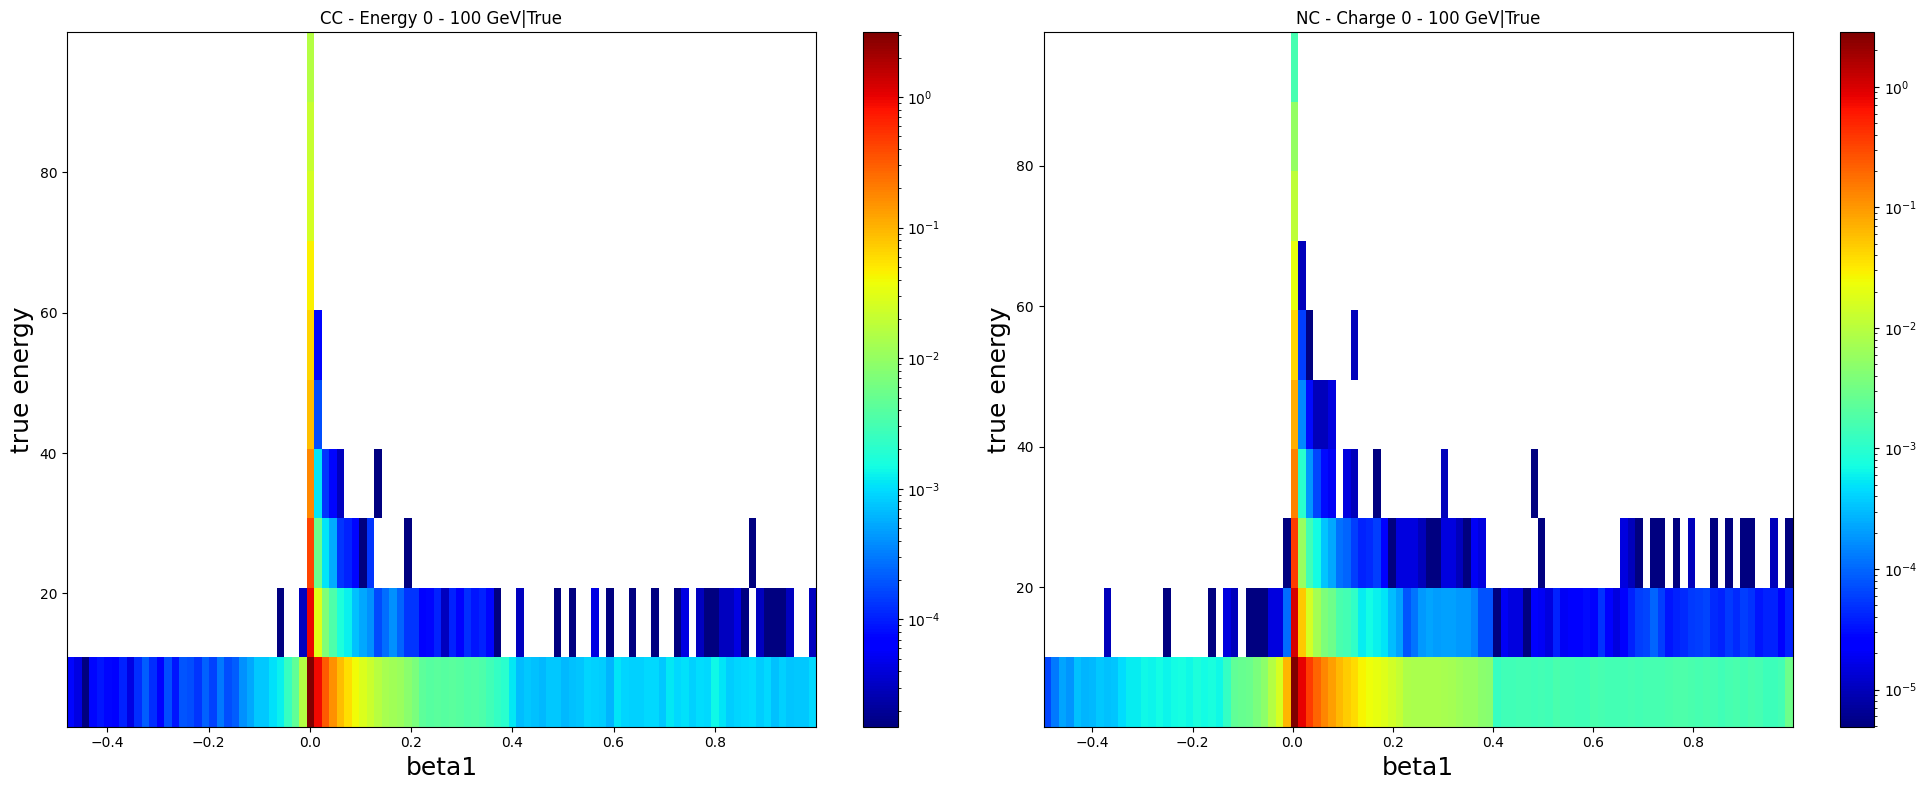

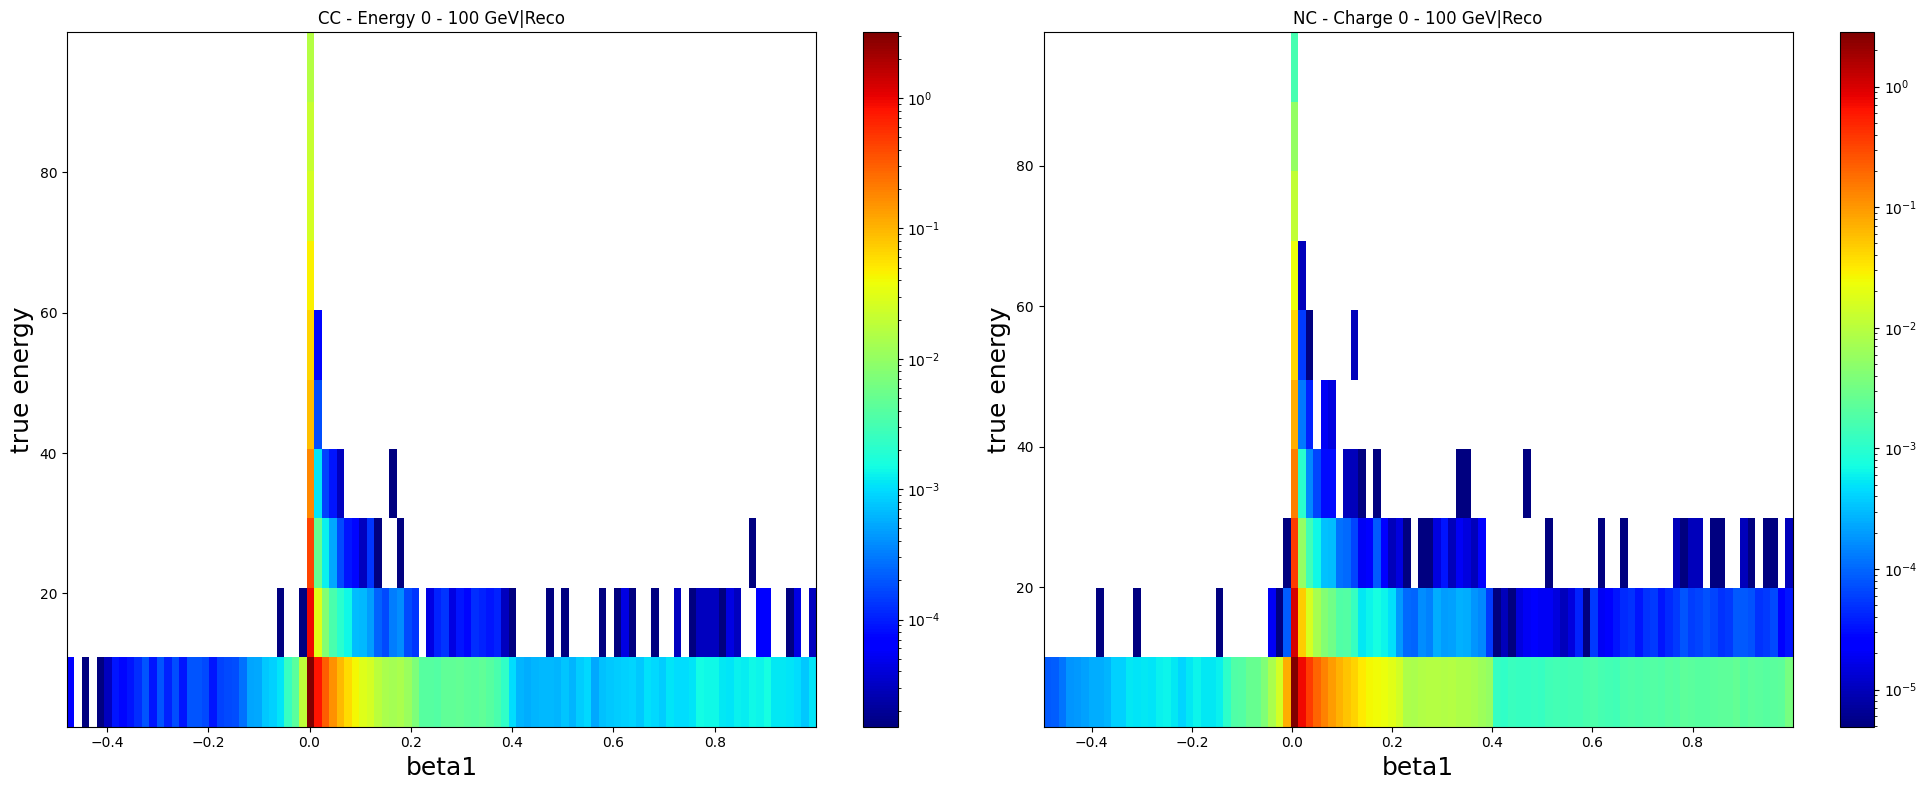

In [6]:
make_plots(fCC.root.Beta1.col('value')[event_booleanCC], fCC.root.PrimaryEnergy.col("value")[event_booleanCC],
           fNC.root.Beta1.col('value')[event_booleanNC], fNC.root.SecondaryEnergy.col("value")[event_booleanNC],
           fCC.root.Beta1Reco.col('value')[event_booleanCC], fCC.root.PrimaryEnergy.col("value")[event_booleanCC],
           fNC.root.Beta1Reco.col('value')[event_booleanNC], fNC.root.SecondaryEnergy.col("value")[event_booleanNC],
           (100, 10), 
           "beta1", "true energy")

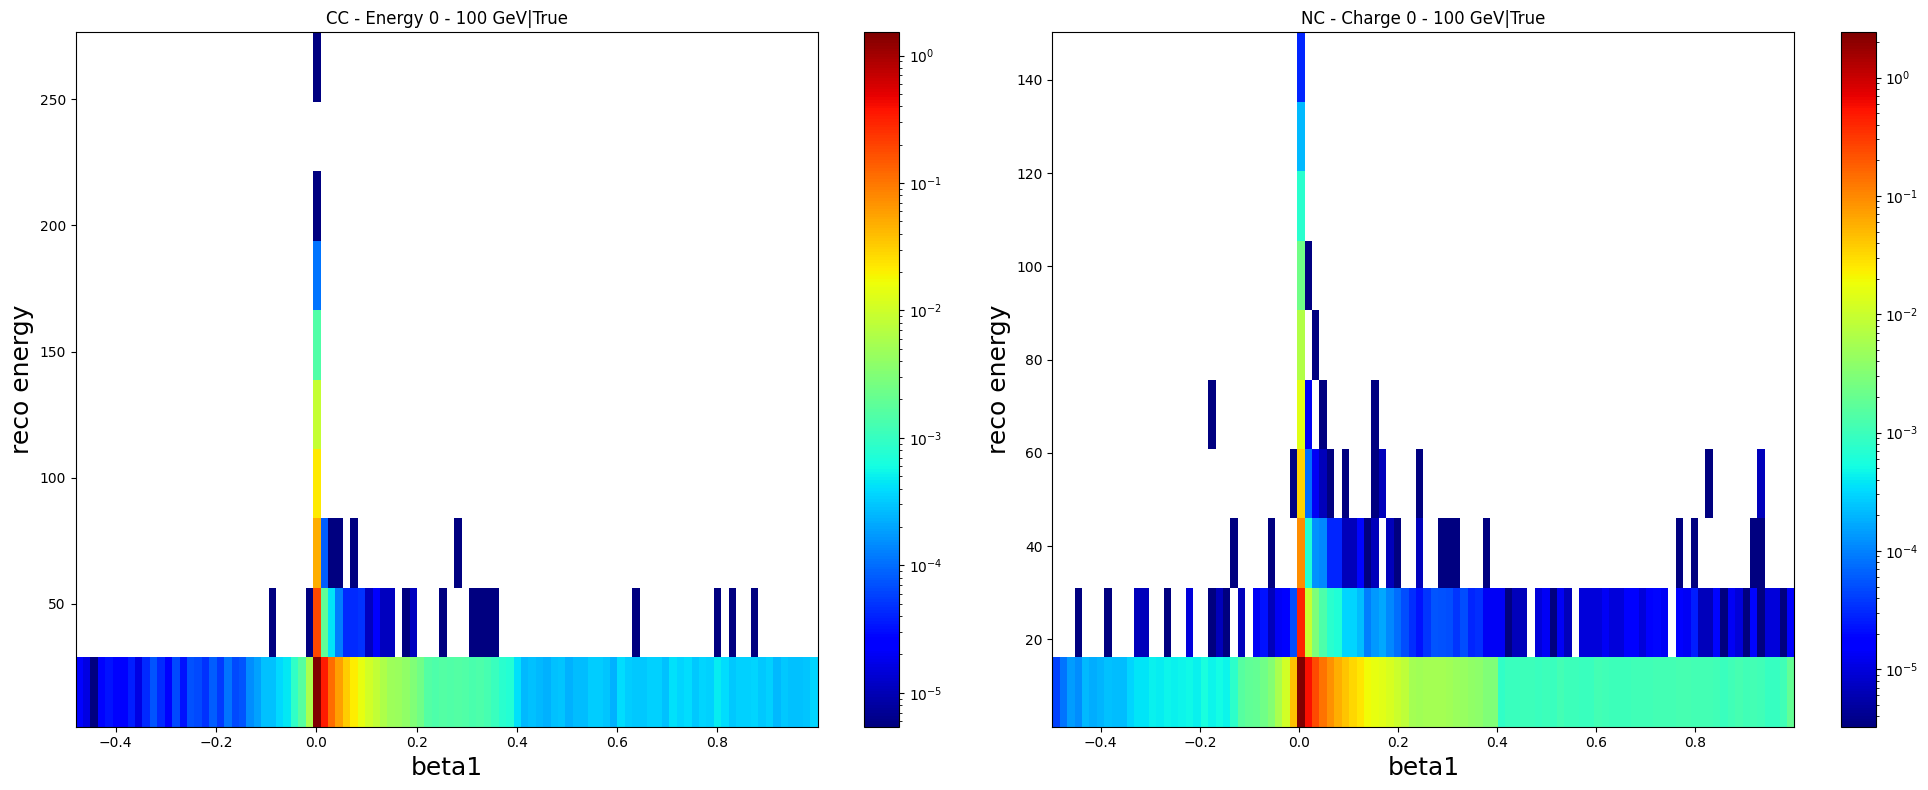

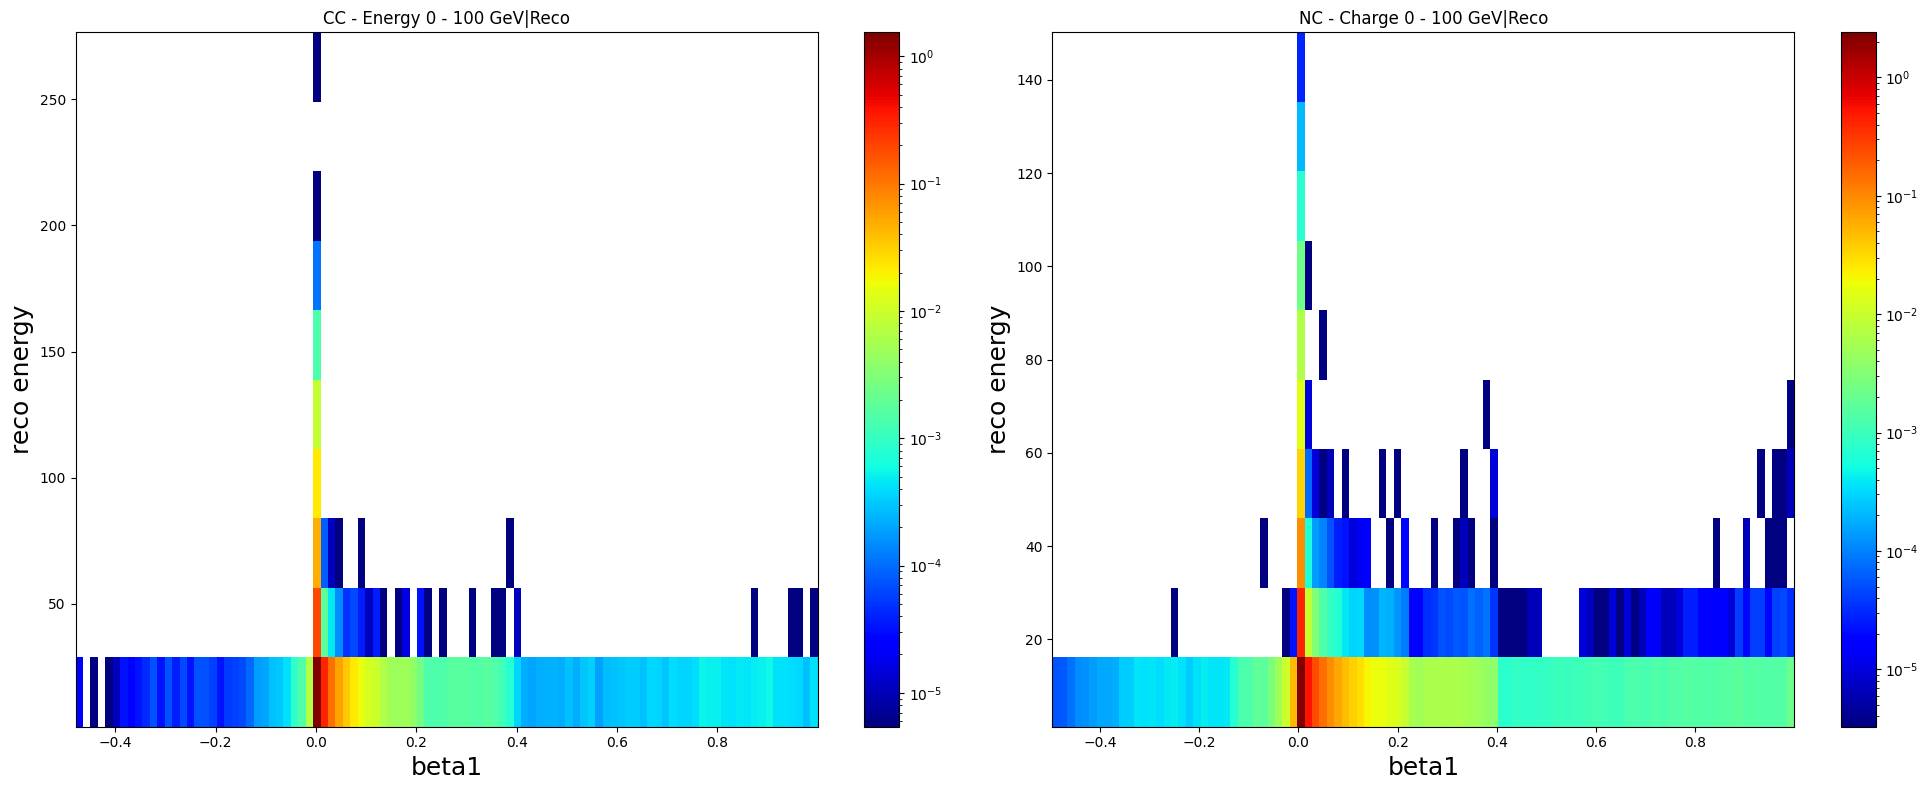

In [7]:
make_plots(fCC.root.Beta1.col('value')[event_booleanCC], fCC.root.RecoEnergy.col("value")[event_booleanCC],
           fNC.root.Beta1.col('value')[event_booleanNC], fNC.root.RecoEnergy.col("value")[event_booleanNC],
           fCC.root.Beta1Reco.col('value')[event_booleanCC], fCC.root.RecoEnergy.col("value")[event_booleanCC],
           fNC.root.Beta1Reco.col('value')[event_booleanNC], fNC.root.RecoEnergy.col("value")[event_booleanNC],
           (100, 10), 
           "beta1", "reco energy")

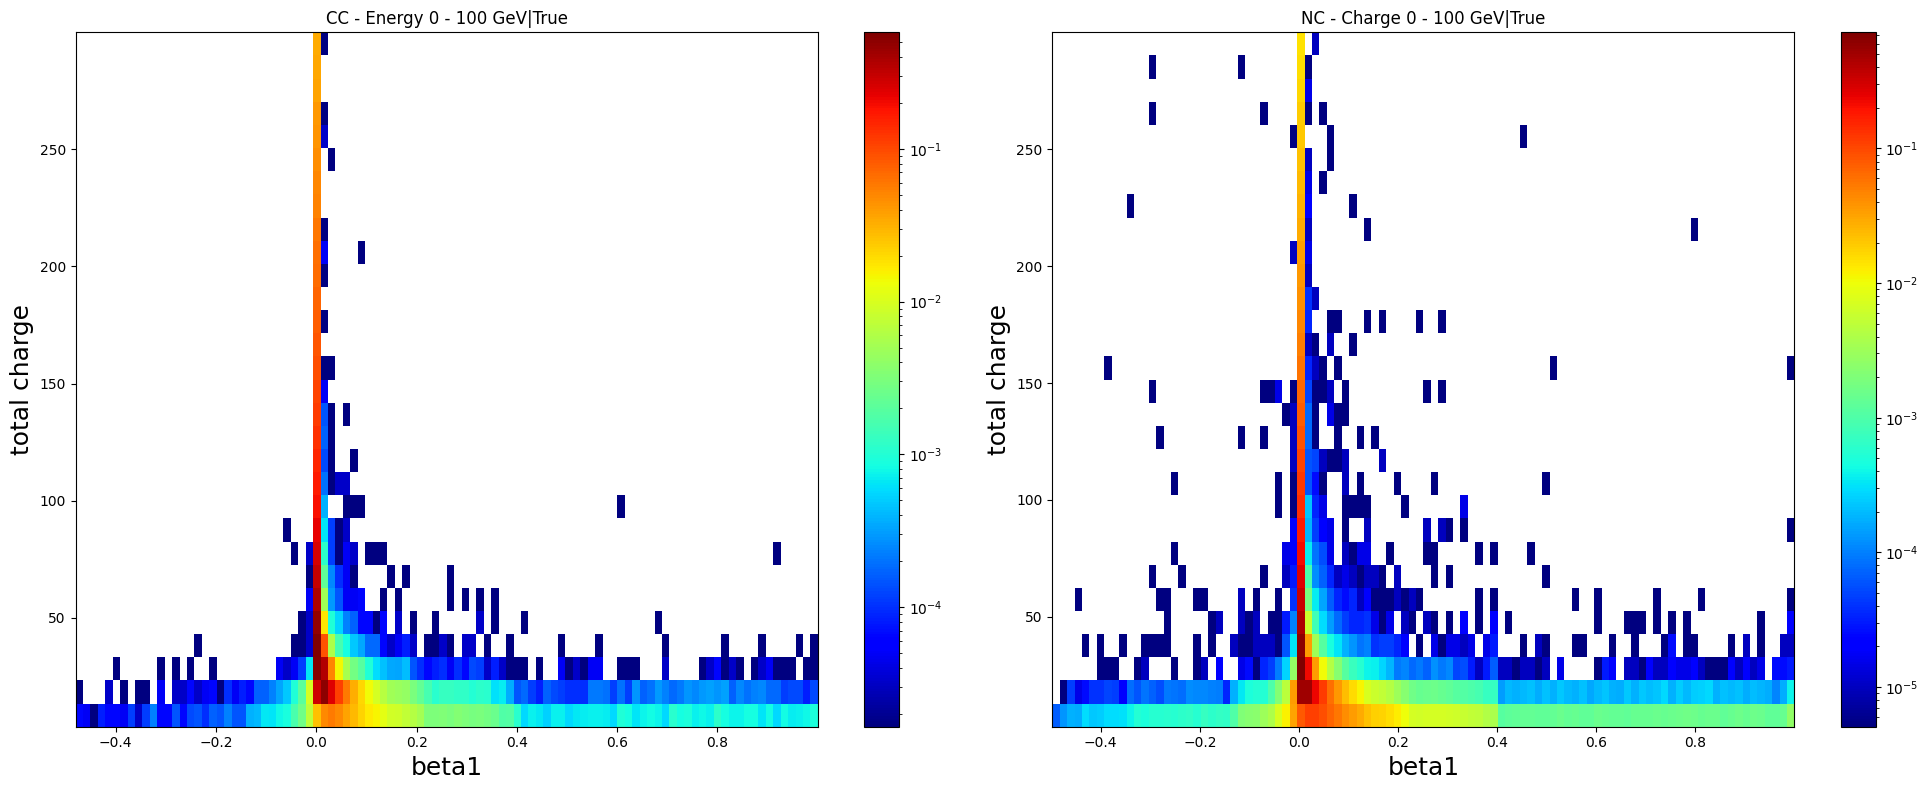

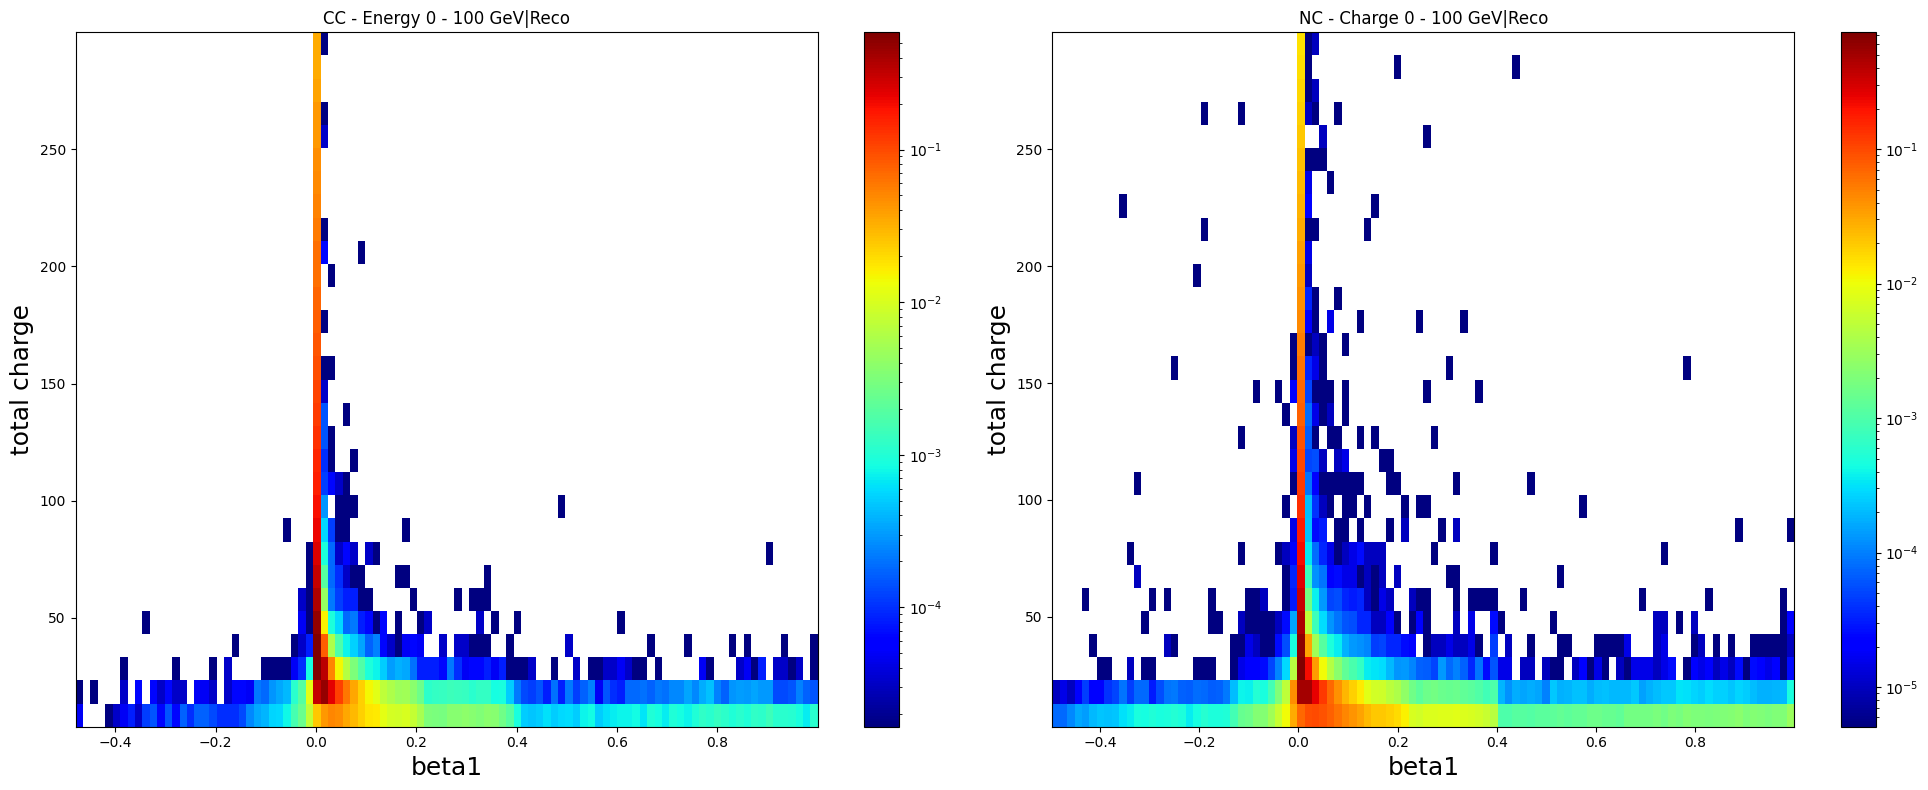

In [8]:
make_plots(fCC.root.Beta1.col('value')[event_booleanCC][fCC.root.TotalCharge.col("value")[event_booleanCC] <300], fCC.root.TotalCharge.col("value")[event_booleanCC][fCC.root.TotalCharge.col("value")[event_booleanCC] <300],
           fNC.root.Beta1.col('value')[event_booleanNC][fNC.root.TotalCharge.col("value")[event_booleanNC] <300], fNC.root.TotalCharge.col("value")[event_booleanNC][fNC.root.TotalCharge.col("value")[event_booleanNC] <300],
           fCC.root.Beta1Reco.col('value')[event_booleanCC][fCC.root.TotalCharge.col("value")[event_booleanCC] <300], fCC.root.TotalCharge.col("value")[event_booleanCC][fCC.root.TotalCharge.col("value")[event_booleanCC] <300],
           fNC.root.Beta1Reco.col('value')[event_booleanNC][fNC.root.TotalCharge.col("value")[event_booleanNC] <300], fNC.root.TotalCharge.col("value")[event_booleanNC][fNC.root.TotalCharge.col("value")[event_booleanNC] <300],
           (100, 30), 
           "beta1", "total charge")

In [9]:
def get_statistic(xCC, xNC, diff_varCC, diff_varNC):
    sep_var = []
    p_val = []
    bin_centers = []

    #charge_val = [10, 50, 100, 150, 200, 250]
    
    for i in range(0, 10): #range(0, len(charge_val)-1):#
        qmin= i*10 #charge_val[i]#
        qmax= (i+1)*10 #charge_val[i+1]#
        
        maskCC = (diff_varCC>=qmin)&(diff_varCC<=qmax)
        maskNC = (diff_varNC>=qmin)&(diff_varNC<=qmax)
        
        if len(xCC[maskCC]) != 0 and len( xNC[maskNC]) != 0:
            #print(qmin, qmax)
            #print(len(tResCC[maskCC]), len( tResNC[maskNC]))
            
            ks_statistic, pvalue = ks_2samp(xCC[maskCC], xNC[maskNC])

            #plt.hist(xCC[maskCC], bins=100, histtype='step', log=True, density=True, label='CC', lw=2)
            #plt.hist(xNC[maskNC], bins=100, histtype='step', log=True, density=True, label='NC', lw=2)
            #plt.title(np.round(ks_statistic, 3))
            #plt.show()
            
            sep_var.append(ks_statistic)
            p_val.append(pvalue)
            bin_centers.append(qmax - 5)

    return sep_var, p_val, bin_centers

In [10]:
sep_var_true_true, p_val_true_true, bin_centers_true_true = get_statistic(fCC.root.Beta1.col('value')[event_booleanCC], fNC.root.Beta1.col('value')[event_booleanNC], 
                                              fCC.root.PrimaryEnergy.col("value")[event_booleanCC], fNC.root.SecondaryEnergy.col("value")[event_booleanNC])

sep_var_true, p_val_true, bin_centers_true = get_statistic(fCC.root.Beta1Reco.col('value')[event_booleanCC], fNC.root.Beta1Reco.col('value')[event_booleanNC], 
                                              fCC.root.PrimaryEnergy.col("value")[event_booleanCC], fNC.root.SecondaryEnergy.col("value")[event_booleanNC])

sep_var_reco, p_val_reco, bin_centers_reco = get_statistic(fCC.root.Beta1Reco.col('value')[event_booleanCC], fNC.root.Beta1Reco.col('value')[event_booleanNC], 
                                              fCC.root.RecoEnergy.col("value")[event_booleanCC], fNC.root.RecoEnergy.col("value")[event_booleanNC])

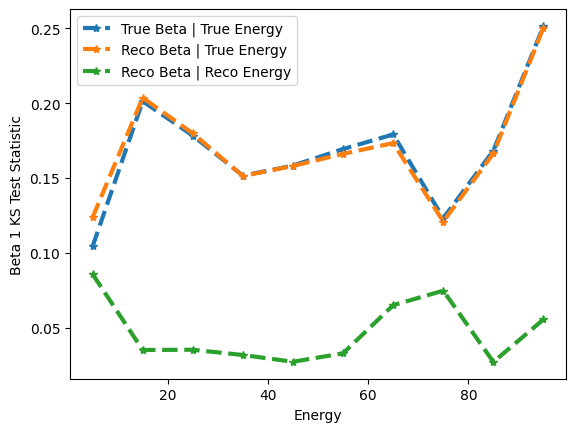

In [11]:
plt.plot(bin_centers_true_true, sep_var_true_true, '*--', linewidth=3, label='True Beta | True Energy')
plt.plot(bin_centers_true, sep_var_true, '*--', linewidth=3, label='Reco Beta | True Energy')
plt.plot(bin_centers_reco, sep_var_reco, '*--', linewidth=3, label='Reco Beta | Reco Energy')
plt.ylabel('Beta 1 KS Test Statistic')
plt.xlabel('Energy')
plt.legend()

In [12]:
sep_var_beta1_true, p_val_beta1_true, bin_centers_beta1_true = get_statistic(fCC.root.Beta1.col('value')[event_booleanCC], 
                                                                             fNC.root.Beta1.col('value')[event_booleanNC], 
                                                                             fCC.root.PrimaryEnergy.col("value")[event_booleanCC], 
                                                                             fNC.root.SecondaryEnergy.col("value")[event_booleanNC])

sep_var_beta1_reco, p_val_beta1_reco, bin_centers_beta1_reco = get_statistic(fCC.root.Beta1Reco.col('value')[event_booleanCC], 
                                                                             fNC.root.Beta1Reco.col('value')[event_booleanNC], 
                                                                             fCC.root.RecoEnergy.col("value")[event_booleanCC], 
                                                                             fNC.root.RecoEnergy.col("value")[event_booleanNC])

sep_var_beta2_true, p_val_beta2_true, bin_centers_beta2_true = get_statistic(fCC.root.Beta2.col('value')[event_booleanCC], 
                                                                             fNC.root.Beta2.col('value')[event_booleanNC], 
                                                                             fCC.root.PrimaryEnergy.col("value")[event_booleanCC], 
                                                                             fNC.root.SecondaryEnergy.col("value")[event_booleanNC])

sep_var_beta2_reco, p_val_beta2_reco, bin_centers_beta2_reco = get_statistic(fCC.root.Beta2Reco.col('value')[event_booleanCC], 
                                                                             fNC.root.Beta2Reco.col('value')[event_booleanNC], 
                                                                             fCC.root.RecoEnergy.col("value")[event_booleanCC], 
                                                                             fNC.root.RecoEnergy.col("value")[event_booleanNC])

sep_var_beta3_true, p_val_beta3_true, bin_centers_beta3_true = get_statistic(fCC.root.Beta3.col('value')[event_booleanCC], 
                                                                             fNC.root.Beta3.col('value')[event_booleanNC], 
                                                                             fCC.root.PrimaryEnergy.col("value")[event_booleanCC], 
                                                                             fNC.root.SecondaryEnergy.col("value")[event_booleanNC])

sep_var_beta3_reco, p_val_beta3_reco, bin_centers_beta3_reco = get_statistic(fCC.root.Beta3Reco.col('value')[event_booleanCC], 
                                                                             fNC.root.Beta3Reco.col('value')[event_booleanNC], 
                                                                             fCC.root.RecoEnergy.col("value")[event_booleanCC], 
                                                                             fNC.root.RecoEnergy.col("value")[event_booleanNC])

sep_var_beta4_true, p_val_beta4_true, bin_centers_beta4_true = get_statistic(fCC.root.Beta4.col('value')[event_booleanCC], 
                                                                             fNC.root.Beta4.col('value')[event_booleanNC], 
                                                                             fCC.root.PrimaryEnergy.col("value")[event_booleanCC], 
                                                                             fNC.root.SecondaryEnergy.col("value")[event_booleanNC])

sep_var_beta4_reco, p_val_beta4_reco, bin_centers_beta4_reco = get_statistic(fCC.root.Beta4Reco.col('value')[event_booleanCC], 
                                                                             fNC.root.Beta4Reco.col('value')[event_booleanNC], 
                                                                             fCC.root.RecoEnergy.col("value")[event_booleanCC], 
                                                                             fNC.root.RecoEnergy.col("value")[event_booleanNC])

sep_var_beta5_true, p_val_beta5_true, bin_centers_beta5_true = get_statistic(fCC.root.Beta5.col('value')[event_booleanCC], 
                                                                             fNC.root.Beta5.col('value')[event_booleanNC], 
                                                                             fCC.root.PrimaryEnergy.col("value")[event_booleanCC], 
                                                                             fNC.root.SecondaryEnergy.col("value")[event_booleanNC])

sep_var_beta5_reco, p_val_beta5_reco, bin_centers_beta5_reco = get_statistic(fCC.root.Beta5Reco.col('value')[event_booleanCC], 
                                                                             fNC.root.Beta5Reco.col('value')[event_booleanNC], 
                                                                             fCC.root.RecoEnergy.col("value")[event_booleanCC], 
                                                                             fNC.root.RecoEnergy.col("value")[event_booleanNC])

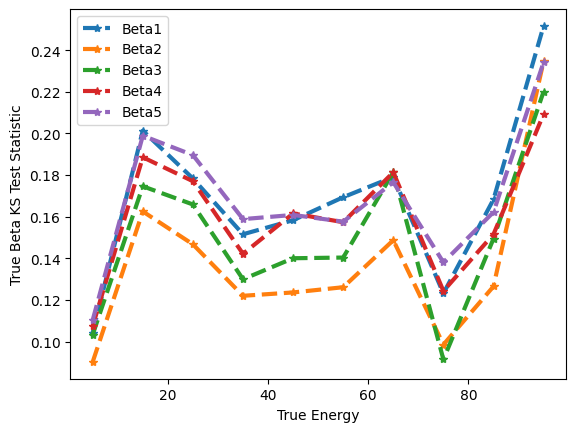

In [13]:
plt.plot(bin_centers_beta1_true, sep_var_beta1_true, '*--', linewidth=3, label='Beta1')
plt.plot(bin_centers_beta2_true, sep_var_beta2_true, '*--', linewidth=3, label='Beta2')
plt.plot(bin_centers_beta3_true, sep_var_beta3_true, '*--', linewidth=3, label='Beta3')
plt.plot(bin_centers_beta4_true, sep_var_beta4_true, '*--', linewidth=3, label='Beta4')
plt.plot(bin_centers_beta5_true, sep_var_beta5_true, '*--', linewidth=3, label='Beta5')

plt.ylabel('True Beta KS Test Statistic')
plt.xlabel('True Energy')

plt.legend()

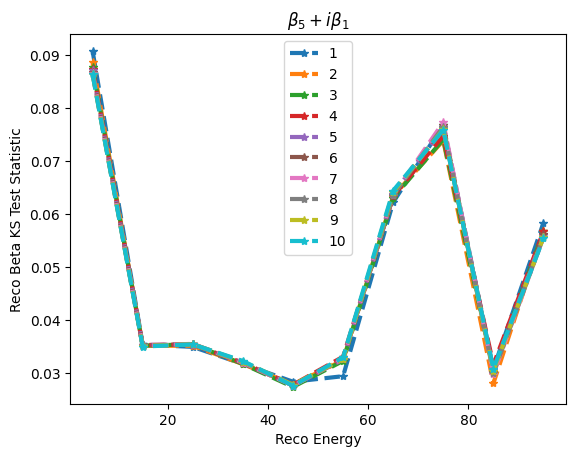

In [54]:
seperation_var_true, p_val_true, bin_centers_true = [], [], []

for i in range(1, 11):
    s, p, b = get_statistic(fCC.root.Beta5Reco.col('value')[event_booleanCC]+(i*fCC.root.Beta1Reco.col('value')[event_booleanCC]), 
                            fNC.root.Beta5Reco.col('value')[event_booleanNC]+(i*fNC.root.Beta1Reco.col('value')[event_booleanNC]), 
                            fCC.root.RecoEnergy.col("value")[event_booleanCC], 
                            fNC.root.RecoEnergy.col("value")[event_booleanNC])

    plt.plot(b, s, '*--', linewidth=3, label=i)

plt.ylabel('Reco Beta KS Test Statistic')
plt.xlabel('Reco Energy')

plt.legend()
plt.title( r'$\beta_5 + i\beta_1$')
plt.show()

In [29]:
fCC.root.Beta5Reco.col('value')[event_booleanCC]+(i*fCC.root.Beta1Reco.col('value')[event_booleanCC])

array([ 1.17691223e+00,  2.70201207e-02, -1.77588887e-03, ...,
        3.49347874e-05,  1.93442790e-03,  8.49417042e-03])

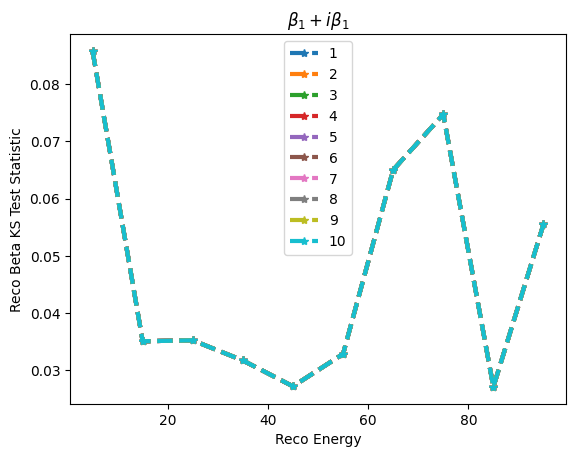

In [34]:
seperation_var_true, p_val_true, bin_centers_true = [], [], []

for i in range(1, 11):
    s, p, b = get_statistic(fCC.root.Beta1Reco.col('value')[event_booleanCC]+(i*fCC.root.Beta1Reco.col('value')[event_booleanCC]), 
                            fNC.root.Beta1Reco.col('value')[event_booleanNC]+(i*fNC.root.Beta1Reco.col('value')[event_booleanNC]), 
                            fCC.root.RecoEnergy.col("value")[event_booleanCC], 
                            fNC.root.RecoEnergy.col("value")[event_booleanNC])

    plt.plot(b, s, '*--', linewidth=3, label=i)

plt.ylabel('Reco Beta KS Test Statistic')
plt.xlabel('Reco Energy')

plt.legend()
plt.title( r'$\beta_1 + i\beta_1$')
plt.show()

In [ ]:
seperation_var_true, p_val_true, bin_centers_true = [], [], []

for i in range(1, 11):
    s, p, b = get_statistic(fCC.root.Beta1Reco.col('value')[event_booleanCC]+(i*fCC.root.Beta1Reco.col('value')[event_booleanCC]), 
                            fNC.root.Beta1Reco.col('value')[event_booleanNC]+(i*fNC.root.Beta1Reco.col('value')[event_booleanNC]), 
                            fCC.root.RecoEnergy.col("value")[event_booleanCC], 
                            fNC.root.RecoEnergy.col("value")[event_booleanNC])

    plt.plot(b, s, '*--', linewidth=3, label=i)

plt.ylabel('Reco Beta KS Test Statistic')
plt.xlabel('Reco Energy')

plt.legend()
plt.title( r'$\beta_1 + i\beta_1$')
plt.show()

In [ ]:
sep_var_beta5_reco, p_val_beta5_reco, bin_centers_beta5_reco = get_statistic(fCC.root.Beta5Reco.col('value')[event_booleanCC], 
                                                                             fNC.root.Beta5Reco.col('value')[event_booleanNC], 
                                                                             fCC.root.RecoEnergy.col("value")[event_booleanCC], 
                                                                             fNC.root.RecoEnergy.col("value")[event_booleanNC])

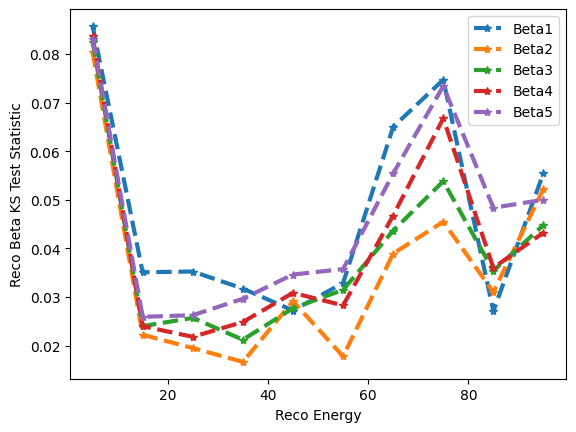

In [20]:
plt.plot(bin_centers_beta1_reco, sep_var_beta1_reco, '*--', linewidth=3, label='Beta1')
plt.plot(bin_centers_beta2_reco, sep_var_beta2_reco, '*--', linewidth=3, label='Beta2')
plt.plot(bin_centers_beta3_reco, sep_var_beta3_reco, '*--', linewidth=3, label='Beta3')
plt.plot(bin_centers_beta4_reco, sep_var_beta4_reco, '*--', linewidth=3, label='Beta4')
plt.plot(bin_centers_beta5_reco, sep_var_beta5_reco, '*--', linewidth=3, label='Beta5')

plt.ylabel('Reco Beta KS Test Statistic')
plt.xlabel('Reco Energy')

plt.legend()

In [42]:
def get_statistic_charge(xCC, xNC, diff_varCC, diff_varNC):
    sep_var = []
    p_val = []
    bin_centers = []

    #charge_val = [10, 50, 100, 150, 200, 250]
    
    for i in range(0, 30): #range(0, len(charge_val)-1):#
        qmin= i*10 #charge_val[i]#
        qmax= (i+1)*10 #charge_val[i+1]#
        
        maskCC = (diff_varCC>=qmin)&(diff_varCC<=qmax)
        maskNC = (diff_varNC>=qmin)&(diff_varNC<=qmax)
        
        if len(xCC[maskCC]) != 0 and len( xNC[maskNC]) != 0:
            #print(qmin, qmax)
            #print(len(tResCC[maskCC]), len( tResNC[maskNC]))
            
            ks_statistic, pvalue = ks_2samp(xCC[maskCC], xNC[maskNC])

            #plt.hist(xCC[maskCC], bins=100, histtype='step', log=True, density=True, label='CC', lw=2)
            #plt.hist(xNC[maskNC], bins=100, histtype='step', log=True, density=True, label='NC', lw=2)
            #plt.title(np.round(ks_statistic, 3))
            #plt.show()
            
            sep_var.append(ks_statistic)
            p_val.append(pvalue)
            bin_centers.append(qmax - 5)

    return sep_var, p_val, bin_centers

In [43]:
sep_var_reco_charge, p_val_reco_charge, bin_centers_reco_charge = get_statistic_charge(fCC.root.Beta1Reco.col('value')[event_booleanCC], fNC.root.Beta1Reco.col('value')[event_booleanNC], 
                                              fCC.root.TotalCharge.col("value")[event_booleanCC], fNC.root.TotalCharge.col("value")[event_booleanNC])

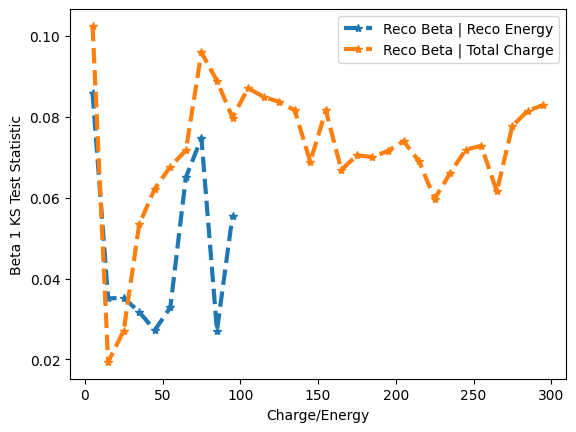

In [44]:
plt.plot(bin_centers_reco, sep_var_reco, '*--', linewidth=3, label='Reco Beta | Reco Energy')
plt.plot(bin_centers_reco_charge, sep_var_reco_charge, '*--', linewidth=3, label='Reco Beta | Total Charge')
plt.ylabel('Beta 1 KS Test Statistic')
plt.xlabel('Charge/Energy')
plt.legend()

In [45]:
sep_var_beta1_true_charge, p_val_beta1_true_charge, bin_centers_beta1_true_charge = get_statistic_charge(fCC.root.Beta1.col('value')[event_booleanCC], 
                                                                                       fNC.root.Beta1.col('value')[event_booleanNC], 
                                                                                       fCC.root.TotalCharge.col("value")[event_booleanCC], 
                                                                                       fNC.root.TotalCharge.col("value")[event_booleanNC])

sep_var_beta1_reco_charge, p_val_beta1_reco_charge, bin_centers_beta1_reco_charge = get_statistic_charge(fCC.root.Beta1Reco.col('value')[event_booleanCC], 
                                                                                       fNC.root.Beta1Reco.col('value')[event_booleanNC], 
                                                                                       fCC.root.TotalCharge.col("value")[event_booleanCC], 
                                                                                       fNC.root.TotalCharge.col("value")[event_booleanNC])

sep_var_beta2_true_charge, p_val_beta2_true_charge, bin_centers_beta2_true_charge = get_statistic_charge(fCC.root.Beta2.col('value')[event_booleanCC], 
                                                                                       fNC.root.Beta2.col('value')[event_booleanNC], 
                                                                                       fCC.root.TotalCharge.col("value")[event_booleanCC], 
                                                                                       fNC.root.TotalCharge.col("value")[event_booleanNC])

sep_var_beta2_reco_charge, p_val_beta2_reco_charge, bin_centers_beta2_reco_charge = get_statistic_charge(fCC.root.Beta2Reco.col('value')[event_booleanCC], 
                                                                                       fNC.root.Beta2Reco.col('value')[event_booleanNC], 
                                                                                       fCC.root.TotalCharge.col("value")[event_booleanCC], 
                                                                                       fNC.root.TotalCharge.col("value")[event_booleanNC])

sep_var_beta3_true_charge, p_val_beta3_true_charge, bin_centers_beta3_true_charge = get_statistic_charge(fCC.root.Beta3.col('value')[event_booleanCC], 
                                                                                       fNC.root.Beta3.col('value')[event_booleanNC], 
                                                                                       fCC.root.TotalCharge.col("value")[event_booleanCC], 
                                                                                       fNC.root.TotalCharge.col("value")[event_booleanNC])

sep_var_beta3_reco_charge, p_val_beta3_reco_charge, bin_centers_beta3_reco_charge = get_statistic_charge(fCC.root.Beta3Reco.col('value')[event_booleanCC], 
                                                                                       fNC.root.Beta3Reco.col('value')[event_booleanNC], 
                                                                                       fCC.root.TotalCharge.col("value")[event_booleanCC], 
                                                                                       fNC.root.TotalCharge.col("value")[event_booleanNC])

sep_var_beta4_true_charge, p_val_beta4_true_charge, bin_centers_beta4_true_charge = get_statistic_charge(fCC.root.Beta4.col('value')[event_booleanCC], 
                                                                                       fNC.root.Beta4.col('value')[event_booleanNC], 
                                                                                       fCC.root.TotalCharge.col("value")[event_booleanCC], 
                                                                                       fNC.root.TotalCharge.col("value")[event_booleanNC])

sep_var_beta4_reco_charge, p_val_beta4_reco_charge, bin_centers_beta4_reco_charge = get_statistic_charge(fCC.root.Beta4Reco.col('value')[event_booleanCC], 
                                                                                       fNC.root.Beta4Reco.col('value')[event_booleanNC], 
                                                                                       fCC.root.TotalCharge.col("value")[event_booleanCC], 
                                                                                       fNC.root.TotalCharge.col("value")[event_booleanNC])

sep_var_beta5_true_charge, p_val_beta5_true_charge, bin_centers_beta5_true_charge = get_statistic_charge(fCC.root.Beta5.col('value')[event_booleanCC], 
                                                                                       fNC.root.Beta5.col('value')[event_booleanNC], 
                                                                                       fCC.root.TotalCharge.col("value")[event_booleanCC], 
                                                                                       fNC.root.TotalCharge.col("value")[event_booleanNC])

sep_var_beta5_reco_charge, p_val_beta5_reco_charge, bin_centers_beta5_reco_charge = get_statistic_charge(fCC.root.Beta5Reco.col('value')[event_booleanCC], 
                                                                                       fNC.root.Beta5Reco.col('value')[event_booleanNC], 
                                                                                       fCC.root.TotalCharge.col("value")[event_booleanCC], 
                                                                                       fNC.root.TotalCharge.col("value")[event_booleanNC])

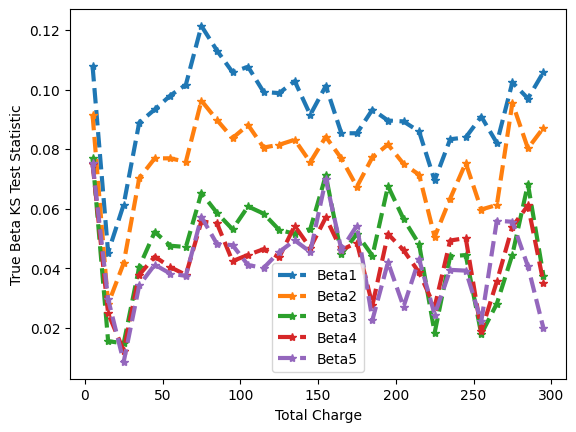

In [46]:
plt.plot(bin_centers_beta1_true_charge, sep_var_beta1_true_charge, '*--', linewidth=3, label='Beta1')
plt.plot(bin_centers_beta2_true_charge, sep_var_beta2_true_charge, '*--', linewidth=3, label='Beta2')
plt.plot(bin_centers_beta3_true_charge, sep_var_beta3_true_charge, '*--', linewidth=3, label='Beta3')
plt.plot(bin_centers_beta4_true_charge, sep_var_beta4_true_charge, '*--', linewidth=3, label='Beta4')
plt.plot(bin_centers_beta5_true_charge, sep_var_beta5_true_charge, '*--', linewidth=3, label='Beta5')

plt.ylabel('True Beta KS Test Statistic')
plt.xlabel('Total Charge')

plt.legend()

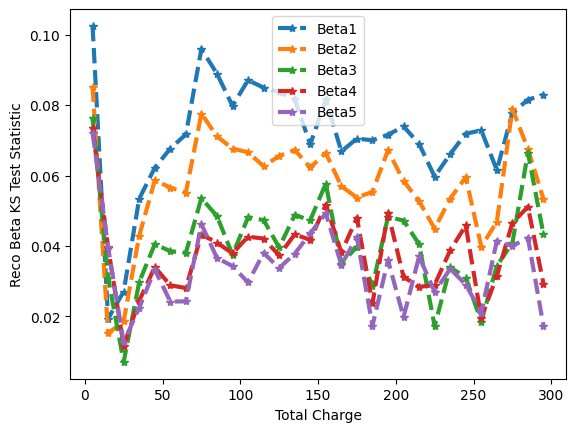

In [47]:
plt.plot(bin_centers_beta1_reco_charge, sep_var_beta1_reco_charge, '*--', linewidth=3, label='Beta1')
plt.plot(bin_centers_beta2_reco_charge, sep_var_beta2_reco_charge, '*--', linewidth=3, label='Beta2')
plt.plot(bin_centers_beta3_reco_charge, sep_var_beta3_reco_charge, '*--', linewidth=3, label='Beta3')
plt.plot(bin_centers_beta4_reco_charge, sep_var_beta4_reco_charge, '*--', linewidth=3, label='Beta4')
plt.plot(bin_centers_beta5_reco_charge, sep_var_beta5_reco_charge, '*--', linewidth=3, label='Beta5')

plt.ylabel('Reco Beta KS Test Statistic')
plt.xlabel('Total Charge')

plt.legend()

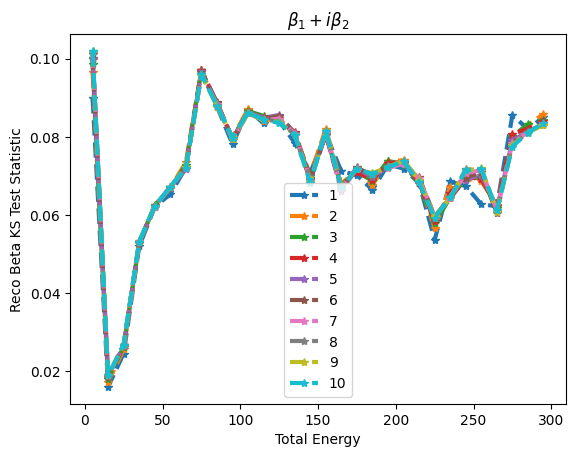

In [53]:
seperation_var_true, p_val_true, bin_centers_true = [], [], []

for i in range(1, 11):
    s, p, b = get_statistic_charge(fCC.root.Beta5Reco.col('value')[event_booleanCC]+(i*fCC.root.Beta1Reco.col('value')[event_booleanCC]), 
                            fNC.root.Beta5Reco.col('value')[event_booleanNC]+(i*fNC.root.Beta1Reco.col('value')[event_booleanNC]), 
                            fCC.root.TotalCharge.col("value")[event_booleanCC], fNC.root.TotalCharge.col("value")[event_booleanNC])

    plt.plot(b, s, '*--', linewidth=3, label=i)

plt.ylabel('Reco Beta KS Test Statistic')
plt.xlabel('Total Energy')

plt.legend()
plt.title( r'$\beta_1 + i\beta_2$')
plt.show()